A case study using iris dataset for KNN algorithm

In [1]:
# import modules for this project
from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# load iris dataset
iris = datasets.load_iris()
data, labels = iris.data, iris.target

# training testing split
res = train_test_split(data, labels,
                       train_size=0.8,
                       test_size=0.2,
                       random_state=12)
train_data, test_data, train_labels, test_labels = res

# Create and fit a nearest-neighbor classifier
from sklearn.neighbors import KNeighborsClassifier
# classifier "out of the box", no parameters
knn = KNeighborsClassifier()
knn.fit(train_data, train_labels)

# print some interested metrics
print("Predictions from the classifier:")
learn_data_predicted = knn.predict(train_data)
print(learn_data_predicted)
print("Target values:")
print(train_labels)
print(accuracy_score(learn_data_predicted, train_labels))

# re-do KNN using some specific parameters.
knn2 = KNeighborsClassifier(algorithm='auto',
                            leaf_size=30,
                            metric='minkowski',
                            p=2,         # p=2 is equivalent to euclidian distance
                            metric_params=None,
                            n_jobs=1,
                            n_neighbors=5,
                            weights='uniform')

knn.fit(train_data, train_labels)
test_data_predicted = knn.predict(test_data)
accuracy_score(test_data_predicted, test_labels)

Predictions from the classifier:
[0 1 2 0 2 0 1 1 0 1 1 0 0 0 0 0 0 0 2 0 2 1 1 1 0 2 1 1 2 0 2 0 2 1 2 2 1
 1 1 2 2 0 2 2 0 1 0 2 2 0 1 1 0 0 1 1 1 1 2 1 2 0 0 1 1 2 0 2 1 0 2 2 1 2
 2 0 0 2 1 1 2 0 1 1 0 1 1 2 2 1 0 2 0 2 0 0 1 2 2 1 2 2 0 1 1 0 2 2 2 1 2
 2 2 0 0 1 0 2 2 1]
Target values:
[0 1 2 0 2 0 1 1 0 1 1 0 0 0 0 0 0 0 2 0 2 1 1 1 0 2 1 1 2 0 2 0 2 2 2 2 1
 1 1 1 2 0 2 2 0 1 0 2 2 0 1 1 0 0 1 1 1 1 2 1 2 0 0 1 1 1 0 2 1 0 2 2 1 2
 2 0 0 2 1 1 2 0 1 1 0 1 1 2 2 1 0 2 0 2 0 0 1 2 2 1 2 2 0 1 1 0 2 2 2 1 2
 2 2 0 0 1 0 2 2 1]
0.975


0.9666666666666667

Use this command to help with choice of paramters in the `KNeighborsClassifier` function.

In [2]:
help(KNeighborsClassifier)

Help on class KNeighborsClassifier in module sklearn.neighbors._classification:

class KNeighborsClassifier(sklearn.neighbors._base.KNeighborsMixin, sklearn.base.ClassifierMixin, sklearn.neighbors._base.NeighborsBase)
 |  KNeighborsClassifier(n_neighbors=5, *, weights='uniform', algorithm='auto', leaf_size=30, p=2, metric='minkowski', metric_params=None, n_jobs=None)
 |  
 |  Classifier implementing the k-nearest neighbors vote.
 |  
 |  Read more in the :ref:`User Guide <classification>`.
 |  
 |  Parameters
 |  ----------
 |  n_neighbors : int, default=5
 |      Number of neighbors to use by default for :meth:`kneighbors` queries.
 |  
 |  weights : {'uniform', 'distance'}, callable or None, default='uniform'
 |      Weight function used in prediction.  Possible values:
 |  
 |      - 'uniform' : uniform weights.  All points in each neighborhood
 |        are weighted equally.
 |      - 'distance' : weight points by the inverse of their distance.
 |        in this case, closer neighb

Use the following code to generate an artificial dataset which contain three classes. Conduct a similar KNN analysis to the dataset and report your accuracy.

In [3]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

centers = [[2, 4], [6, 6], [1, 9]]
n_classes = len(centers)
data, labels = make_blobs(n_samples=150,
                          centers=np.array(centers),
                          random_state=1)
# do a 80-20 split of the data

# perform a KNN analysis of the simulated data

# output accuracy score

# plot your different results



In [5]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

# Define centers for the three classes
centers = [[2, 4], [6, 6], [1, 9]]
n_classes = len(centers)

# Generate the dataset
data, labels = make_blobs(n_samples=150, centers=np.array(centers), random_state=1)

In [6]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, train_size=0.8, test_size=0.2, random_state=12
)

In [7]:
from sklearn.neighbors import KNeighborsClassifier

# Create and fit a KNN classifier with default parameters
knn = KNeighborsClassifier()
knn.fit(train_data, train_labels)

# Predict on the training and testing data
train_predictions = knn.predict(train_data)
test_predictions = knn.predict(test_data)

# Calculate accuracy scores
train_accuracy = accuracy_score(train_predictions, train_labels)
test_accuracy = accuracy_score(test_predictions, test_labels)

print("Training Accuracy (Default KNN):", train_accuracy)
print("Testing Accuracy (Default KNN):", test_accuracy)

Training Accuracy (Default KNN): 1.0
Testing Accuracy (Default KNN): 1.0


In [8]:
# Create and fit a KNN classifier with custom parameters
knn_custom = KNeighborsClassifier(
    n_neighbors=5,
    weights='distance',
    metric='minkowski',
    p=2
)
knn_custom.fit(train_data, train_labels)

# Predict on the training and testing data
train_predictions_custom = knn_custom.predict(train_data)
test_predictions_custom = knn_custom.predict(test_data)

# Calculate accuracy scores
train_accuracy_custom = accuracy_score(train_predictions_custom, train_labels)
test_accuracy_custom = accuracy_score(test_predictions_custom, test_labels)

print("Training Accuracy (Custom KNN):", train_accuracy_custom)
print("Testing Accuracy (Custom KNN):", test_accuracy_custom)

Training Accuracy (Custom KNN): 1.0
Testing Accuracy (Custom KNN): 1.0


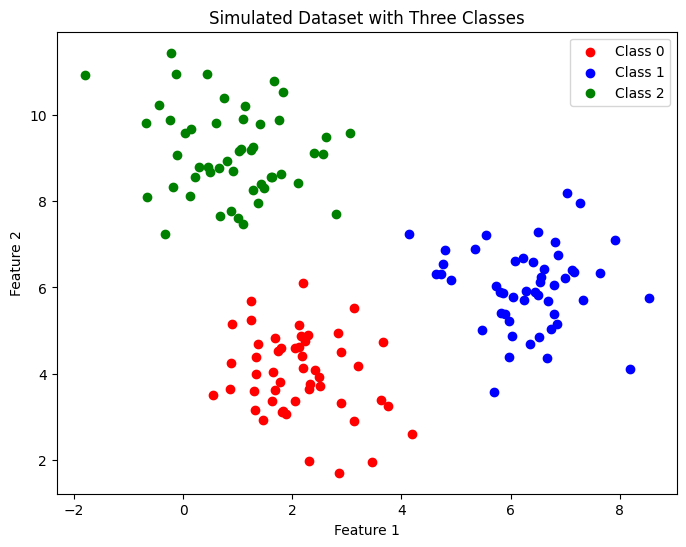

In [9]:
# Plot the simulated dataset
plt.figure(figsize=(8, 6))
for i, color in zip(range(n_classes), ['red', 'blue', 'green']):
    plt.scatter(data[labels == i, 0], data[labels == i, 1], c=color, label=f'Class {i}')
plt.title('Simulated Dataset with Three Classes')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

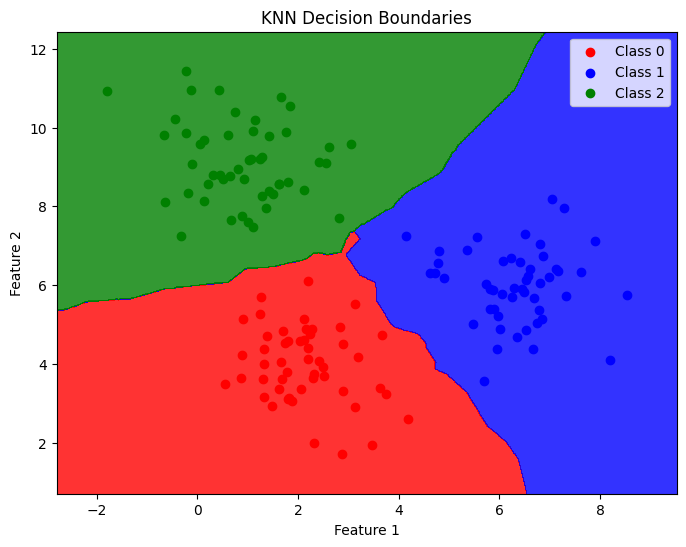

In [10]:
import numpy as np
from matplotlib.colors import ListedColormap

# Create a meshgrid to plot decision boundaries
x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Predict the class for each point in the meshgrid
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundaries
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(['red', 'blue', 'green']))
for i, color in zip(range(n_classes), ['red', 'blue', 'green']):
    plt.scatter(data[labels == i, 0], data[labels == i, 1], c=color, label=f'Class {i}')
plt.title('KNN Decision Boundaries')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()